In [1]:
import os
os.chdir(r"C:\Users\lenovo\Desktop\ML")
print(os.getcwd())

c:\Users\lenovo\Desktop\ML


In [2]:
import pandas as pd
df = pd.read_csv("Housing.csv")
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [3]:
#This is my Task 1:
import pandas as pd
df = pd.read_csv("Housing.csv")
print("First 10 rows:")
display(df.head(10))
print("Shape (rows, columns):", df.shape)
target = "Price"
features = [col for col in df.columns if col != target]
print("Target column:", target)
print("Feature columns:", features)
print("Missing values per column:")
print(df.isnull().sum())

First 10 rows:


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


Shape (rows, columns): (545, 13)
Target column: Price
Feature columns: ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']
Missing values per column:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [4]:
#This is my task 2:
import pandas as pd
df = pd.read_csv("Housing.csv")
for col in df.select_dtypes(include=['int64','float64']).columns:
    df[col].fillna(df[col].median(),inplace=True)
for col in df.select_dtypes(include=['object']).columns:
    df[col].fillna(df[col].mode()[0],inplace=True)
df=df.drop_duplicates()
df=pd.get_dummies(df,drop_first=True)
target="Price"
X=df.drop(columns=[target]) if target in df.columns else None
y=df[target] if target in df.columns else None
print(df.shape)
print(df.isnull().sum().sum())
print(df.duplicated().sum())

(545, 14)
0
0


C:\Users\lenovo\AppData\Local\Temp\ipykernel_1876\1313905930.py:5: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df[col].fillna(df[col].median(),inplace=True)
C:\Users\lenovo\AppData\Local\Temp\ipykernel_1876\1313905930.py:5: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment us

In [5]:
import pandas as pd

df = pd.read_csv("Housing.csv")
print(df.columns)

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='str')


In [6]:
# I am converting category text columns into numeric format because ML models cannot access text directly
# So we are using get_dummies to create binary columns for each category
df = pd.get_dummies(df, drop_first=True)

In [7]:
#This is my Task 3:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
df = pd.read_csv("Housing.csv")
df = pd.get_dummies(df, drop_first=True)
X = df.drop(columns=["price"])
y = df["price"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
def evaluate(y_true, y_pred):
    return (
        mean_absolute_error(y_true, y_pred),
        np.sqrt(mean_squared_error(y_true, y_pred)),
        r2_score(y_true, y_pred)
    )

print("Linear Regression:", evaluate(y_test, lr_pred))
print("Random Forest:", evaluate(y_test, rf_pred))

Linear Regression: (970043.4039201637, np.float64(1324506.9600914388), 0.6529242642153184)
Random Forest: (1021546.0353211008, np.float64(1400565.9728553821), 0.611918531405699)


In [8]:
lr_r2 = r2_score(y_test, lr_pred)
rf_r2 = r2_score(y_test, rf_pred)

In [9]:
print("Linear Regression:", lr_r2)
print("Random Forest:", rf_r2)
if lr_r2 > rf_r2:
    print("Linear Regression performed better")
else:
    print("Random Forest performed better")

Linear Regression: 0.6529242642153184
Random Forest: 0.611918531405699
Linear Regression performed better


In [10]:
import matplotlib.pyplot as plt

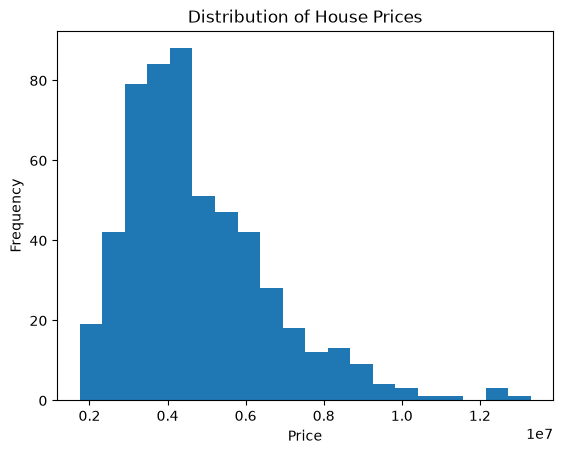

In [11]:
#This is my Task 4:
# Chart 1: Histogram showing the distribution of house prices:
import matplotlib.pyplot as plt
plt.figure()
plt.hist(df["price"], bins=20)
plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

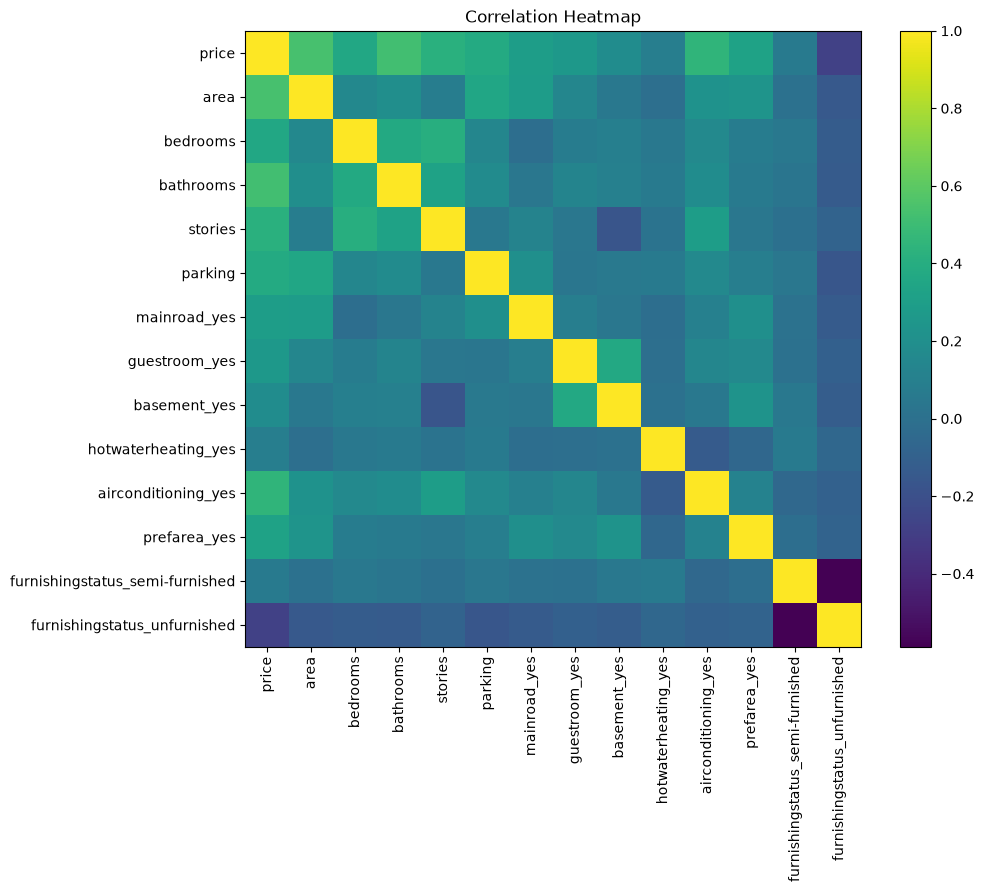

In [12]:
#Chart 2: Correlation heatmap showing which features relate most strongly to price
import matplotlib.pyplot as plt
corr = df.corr()
plt.figure(figsize=(10,8))
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap")
plt.show()

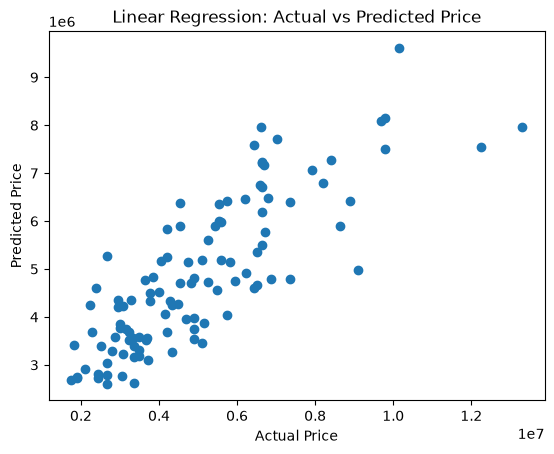

In [13]:
#Chart 3:A chart of my own choice: actual vs. predicted price scatter plot
plt.figure()
plt.scatter(y_test, lr_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Linear Regression: Actual vs Predicted Price")
plt.show()

This is my Task 5:
House prices are most affected by factors like location, no.of bathrooms, and overall condition of furnishing.Features like guest rooms and basements have a moderate impact.
The model's accuracy was moderate, with an R² score between 0.6 and 0.65. This score indicates it explains a decent portion of price variation, but it's not perfect.The predictions are generally close, but there are noticeable errors. 
One surprising finding was that some factors, like the number of stories and parking, had less influence than expected. 
From a business viewpoint, focusing on increasing usable space and improving interior quality would likely have the greatest effect on property value.